In [1]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.transpiler import generate_preset_pass_manager

from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister

PrimitiveResult([SamplerPubResult(data=DataBin(c0=BitArray(<shape=(), num_shots=1024, num_bits=2>), meas=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


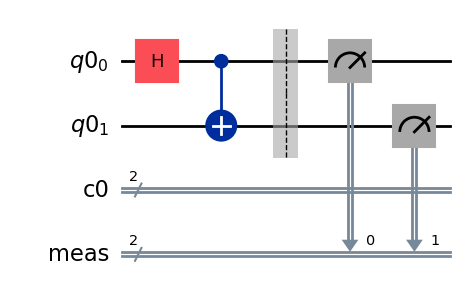

In [2]:
# Quantum circuit to make a Bell state
class_reg = ClassicalRegister(2)
q_reg = QuantumRegister(2)
bell = QuantumCircuit(q_reg, class_reg)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()
#bell.measure([0,1], [0,1])


pm = generate_preset_pass_manager(optimization_level=1)
isa_circuit = pm.run(bell)

# execute the quantum circuit
sampler = Sampler()
job = sampler.run([isa_circuit])
result = job.result()

print(result)
bell.draw('mpl')

In [3]:
bitarray_obj = result[0].data.c0
print(bitarray_obj)

BitArray(<shape=(), num_shots=1024, num_bits=2>)


In [7]:
print(bitarray_obj.array)

[[3]
 [0]
 [3]
 ...
 [3]
 [0]
 [0]]


In [8]:
print(bitarray_obj.ndim)

0


In [14]:
# Number of ones appearing in the binary representation of each shot
print(bitarray_obj.bitcount())
print(len(bitarray_obj.bitcount()))

[2 0 2 ... 2 0 0]
1024


In [15]:
print(bitarray_obj.get_bitstrings())

['11', '00', '11', '00', '00', '11', '00', '11', '00', '00', '11', '00', '11', '11', '11', '11', '11', '11', '11', '00', '11', '11', '11', '11', '00', '00', '11', '11', '11', '00', '00', '00', '00', '11', '00', '11', '00', '11', '11', '11', '00', '11', '00', '00', '11', '11', '11', '00', '00', '11', '00', '00', '11', '00', '00', '00', '00', '11', '00', '00', '11', '11', '00', '00', '11', '11', '00', '11', '11', '00', '11', '00', '00', '00', '00', '11', '11', '00', '00', '11', '11', '11', '00', '11', '00', '00', '00', '00', '11', '11', '00', '11', '00', '00', '00', '00', '00', '11', '11', '00', '11', '00', '11', '11', '00', '00', '11', '00', '11', '11', '11', '11', '00', '11', '00', '11', '00', '00', '00', '11', '11', '11', '00', '00', '11', '11', '00', '11', '11', '00', '11', '00', '11', '11', '11', '11', '00', '00', '11', '00', '00', '11', '00', '00', '00', '00', '11', '00', '11', '11', '11', '00', '00', '00', '00', '00', '00', '11', '11', '00', '11', '00', '00', '11', '00', '11', '11

In [16]:
print(bitarray_obj.get_counts())

{'11': 514, '00': 510}


In [17]:
print(bitarray_obj.get_int_counts())

{3: 514, 0: 510}


In [18]:
print(bitarray_obj.postselect())

TypeError: BitArray.postselect() missing 2 required positional arguments: 'indices' and 'selection'